# Firn temperature calibration — global glenglat grid search

Calibrates two GloGEM firn temperature parameters:
- **`perm_frac`** (0–1): fraction of the Herron-Langway firn-ice transition depth accessible to meltwater
- **`dT_scale`** (0–3): scalar multiplier on the CART-predicted firn insulation correction (surface BC)

**Borehole coverage**: All borehole types are included — accumulation zone, ablation zone, and
boreholes with unidentified mass-balance area. The two parameters are treated zone-aware:
- `dT_scale` only affects firn/accumulation bands in GloGEM (surface BC guard `if firn[i] eq 1`);
  the calibration therefore only fits `dT_scale` from accumulation-zone observations.
- `perm_frac` scales the effective percolation depth for ALL bands; ablation-zone observations
  constrain it independently of `dT_scale`.
- Unidentified boreholes: conservatively treated as accumulation (firn) since most deep-borehole
  studies are in the accumulation area; can be overridden per study.

Workflow:
1. Load ALL glenglat borehole T(z) profiles (accumulation, ablation, unidentified)
2. Assign `is_firn` flag; compute CART dT_firn_band and H-L z_perm per borehole
3. **70/30 stratified split** by climate region
4. Grid search on calibration set → optimal (perm_frac*, dT_scale*) per glacier
5. Fit transfer models: perm_frac from all glaciers; dT_scale from firn-observed glaciers only
6. Validate on held-out 30% set
7. Write calibration file + IDL coefficient block

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

BASE_DIR     = Path('/home/jabeer/projects/glogemflow_development')
GLENGLAT_DIR = BASE_DIR / 'glogemflow_icetemp/glenglat/data'
DATA_DIR     = BASE_DIR / 'glogemflow_icetemp/data'
FIG_DIR      = BASE_DIR / 'glogemflow_icetemp/figures'
TEST_DIR     = BASE_DIR / 'GloGEM/test/data'
FIG_DIR.mkdir(exist_ok=True)

RANDOM_SEED  = 42
CALIB_FRAC   = 0.70   # 70% calibration, 30% validation
MAX_DEPTH    = 80.0   # m  — only use measurements above this depth
MIN_DEPTH    = 5.0    # m  — exclude very shallow measurements (< 5 m)

# CART decision-tree constants (from GloGEM initialise_firnicetemp_spinup.pro)
T_AMP_THRESH   = 20.0
ELEV_MAR_SPLIT = 4300.0
ELEV_CON_SPLIT = 1500.0
DT_MAR_LOW     = 4.40
DT_MAR_HIGH    = 0.54
DT_CON_HIGH    = 7.26
DT_CON_LOW     = 10.34
Z0_FIRN        = 15.0   # m   C&P e-folding depth

# Ice-band insulation fraction: seasonal snow insulates ~40% as much as perennial firn.
# Applied to ablation/ice bands in both the Python model and the IDL surface BC.
ICE_FRAC = 0.4

# Grid search range (1D — only dT_scale is identifiable from annual-mean borehole data)
DT_SCALE_GRID = np.arange(0.1, 3.01, 0.1)   # 30 steps

print(f'Grid size: {len(DT_SCALE_GRID)} dT_scale values')
print(f'Split: {CALIB_FRAC:.0%} calibration / {1-CALIB_FRAC:.0%} validation')

## Helper functions

In [ ]:
def cart_dT_firn(T_amplitude, elevation):
    """CART decision-tree: firn insulation correction ΔT (°C)."""
    if T_amplitude <= T_AMP_THRESH:
        return DT_MAR_LOW if elevation <= ELEV_MAR_SPLIT else DT_MAR_HIGH
    else:
        return DT_CON_HIGH if elevation > ELEV_CON_SPLIT else DT_CON_LOW


def cp_model_single(depth, T_maat, dT_firn_band, dT_scale, is_firn):
    """
    Pure C&P analytical temperature at a single depth — single exponential, no z_perm.

    Matches IDL `initialise_firnicetemp_spinup.pro`:
      te_fit[i,j] = min(0, tt[i] + dT_scale_b[i] * dT_firn_band[i] * exp(-depth/z0_firn))

    is_firn : bool
        True  → full insulation: dT_scale * dT_firn_band
        False → reduced insulation: ICE_FRAC * dT_scale * dT_firn_band
                (seasonal snow on ice ≈ 40% insulation of perennial firn)
    """
    ins = dT_scale * dT_firn_band if is_firn else ICE_FRAC * dT_scale * dT_firn_band
    return min(0.0, T_maat + ins * np.exp(-depth / Z0_FIRN))


def cp_model(depths, T_maat, dT_firn_band, dT_scale, is_firn_arr):
    return np.array([
        cp_model_single(d, T_maat, dT_firn_band, dT_scale, f)
        for d, f in zip(depths, is_firn_arr)
    ])


def rmse(T_mod, T_obs):
    mask = ~np.isnan(T_obs) & ~np.isnan(T_mod)
    if mask.sum() < 2:
        return np.nan
    return np.sqrt(np.mean((T_mod[mask] - T_obs[mask])**2))


print('Helpers defined.')

## Load ALL borehole data (all zones)

`is_firn` assignment:
- `mass_balance_area == 'accumulation'` → True
- `mass_balance_area == 'ablation'`     → False
- empty / NaN                           → True (conservative; most published deep boreholes are in accumulation areas)

For ice/ablation boreholes, `z_perm = Z_PERM_ICE` (30 m default) is used instead of H-L,
matching GloGEM's `firnice_perm_depth` fallback for bands where `firn[i] = 0`.

In [ ]:
derived = pd.read_csv(DATA_DIR / 'glenglat_profiles_derived.csv')
derived['borehole_id'] = derived['borehole_id'].astype(str)
derived['profile_id']  = derived['profile_id'].astype(str)

meas = pd.read_csv(GLENGLAT_DIR / 'measurement.csv')
meas['borehole_id'] = meas['borehole_id'].astype(str)
meas['profile_id']  = meas['profile_id'].astype(str)
meas['depth']       = pd.to_numeric(meas['depth'], errors='coerce')
meas['T_obs']       = pd.to_numeric(meas['temperature'], errors='coerce')

data = meas.merge(
    derived[['borehole_id', 'profile_id', 'glacier_name', 'latitude', 'longitude',
              'elevation', 'mass_balance_area', 'regime', 'glogem_region',
              'T_maat', 'T_amplitude', 'dT_firn']],
    on=['borehole_id', 'profile_id'],
    how='inner'
)
data = data.dropna(subset=['T_obs', 'depth', 'T_maat', 'T_amplitude'])

# Depth filter — include ALL zones
data = data[(data['depth'] >= MIN_DEPTH) & (data['depth'] <= MAX_DEPTH)].copy()

# is_firn: accumulation → True; ablation → False; unknown → True (conservative)
def classify_firn(mba):
    if isinstance(mba, str) and mba.strip() == 'ablation':
        return False
    return True

data['is_firn'] = data['mass_balance_area'].apply(classify_firn)

# Numeric conversions
for col in ('T_maat', 'T_amplitude', 'elevation'):
    data[col] = data[col].astype(float)

# CART insulation per measurement row
data['dT_firn_band'] = data.apply(
    lambda r: cart_dT_firn(r['T_amplitude'], r['elevation']), axis=1)

# Glacier-level summary
glac = (
    data.groupby('glacier_name').agg(
        glogem_region  = ('glogem_region',  'first'),
        T_maat         = ('T_maat',         'mean'),
        T_amplitude    = ('T_amplitude',     'mean'),
        elevation      = ('elevation',       'mean'),
        dT_firn_band   = ('dT_firn_band',   'mean'),
        n_obs          = ('T_obs',           'count'),
        has_firn_obs   = ('is_firn',         'any'),
        has_ice_obs    = ('is_firn',         lambda x: (~x).any()),
    ).reset_index()
)

# Zone breakdown
zone_counts = data['mass_balance_area'].fillna('unknown').value_counts()
print(f'Total measurements: {len(data)}')
print('By mass_balance_area:')
print(zone_counts.to_string())
print(f'\nis_firn=True: {data["is_firn"].sum()}, is_firn=False: {(~data["is_firn"]).sum()}')
print(f'\nGlaciers: {len(glac)} total')
print(f'  with accumulation-zone obs: {glac["has_firn_obs"].sum()}')
print(f'  with ablation-zone obs:     {glac["has_ice_obs"].sum()}')
print(f'  with both zones:            {(glac["has_firn_obs"] & glac["has_ice_obs"]).sum()}')
print('\nGlacier count by region:')
print(glac.groupby('glogem_region').size().to_string())

## 70/30 stratified split
Split at glacier level, stratified by region to cover all climate zones in both sets.

In [4]:
rng = np.random.default_rng(RANDOM_SEED)

calib_glaciers = []
valid_glaciers  = []

for region, grp in glac.groupby('glogem_region'):
    names = grp['glacier_name'].tolist()
    rng.shuffle(names)
    n_calib = max(1, int(round(len(names) * CALIB_FRAC)))
    calib_glaciers.extend(names[:n_calib])
    valid_glaciers.extend(names[n_calib:])

data['split'] = data['glacier_name'].apply(
    lambda g: 'calibration' if g in calib_glaciers else 'validation')

print(f'Calibration: {len(calib_glaciers)} glaciers, '
      f'{(data["split"]=="calibration").sum()} measurements')
print(f'Validation:  {len(valid_glaciers)} glaciers, '
      f'{(data["split"]=="validation").sum()} measurements')
print('\nCalibration glaciers:')
for g in sorted(calib_glaciers): print(f'  {g}')
if valid_glaciers:
    print('\nValidation glaciers:')
    for g in sorted(valid_glaciers): print(f'  {g}')
else:
    print('\n(No validation glaciers — too few glaciers per region for a split)')

Calibration: 24 glaciers, 2048 measurements
Validation:  9 glaciers, 380 measurements

Calibration glaciers:
  Abramov Glacier
  Athabasca Glacier
  Austfonna
  Batysh Sook Glacier
  Bruce Plateau
  Glacier de Tête Rousse
  Glacier des Bossons
  Gornergletscher
  Grenzgletscher
  Hare Glacier
  Illimani Volcano
  John Evans Glacier
  Jungfraufirn
  Laika Ice Cap
  North Glacier
  Qaanaaq Glacier
  Sofiyskiy Glacier
  Vadret dal Corvatsch
  Vestfonna
  Waldemarbreen
  White Glacier
  Ледник Вавилова [Vavilov Glacier]
  Ледник Туюксу Центральный [Central Tuyuksu Glacier]
  西琼台兰冰川 [Xiqiongtailan Glacier]

Validation glaciers:
  Agassiz Ice Cap
  Austre Grønfjordbreen
  Breithornplateau
  Fieschergletscher
  Grigoriev Ice Cap
  Johnsons Glacier
  Vadret da Morteratsch
  Ледник Григорьева [Grigoriev Glacier]
  Ледник Шокальского [Shokalsky Glacier]


## Grid search — calibration set

For each calibration glacier, minimise RMSE over ALL its borehole measurements
(accumulation + ablation + unknown). The per-measurement `is_firn` flag ensures the
analytical model is applied correctly: ablation-zone measurements use no insulation
correction, exactly as GloGEM does at runtime.

In [ ]:
calib_results = []
rmse_grids    = {}

for glacier_name in calib_glaciers:
    gdf = data[data['glacier_name'] == glacier_name].copy()
    if gdf.empty:
        continue

    depths_obs  = gdf['depth'].values
    T_obs       = gdf['T_obs'].values
    is_firn_arr = gdf['is_firn'].values
    T_maat      = gdf['T_maat'].mean()
    dT_fb       = gdf['dT_firn_band'].mean()

    # 1D grid search over dT_scale only
    grid = np.full(len(DT_SCALE_GRID), np.nan)
    for ids, ds in enumerate(DT_SCALE_GRID):
        T_mod = np.array([cp_model_single(d, T_maat, dT_fb, ds, f)
                          for d, f in zip(depths_obs, is_firn_arr)])
        grid[ids] = rmse(T_mod, T_obs)

    rmse_grids[glacier_name] = grid

    best_idx  = np.nanargmin(grid)
    ds_best   = DT_SCALE_GRID[best_idx]
    rmse_best = grid[best_idx]

    T_default    = np.array([cp_model_single(d, T_maat, dT_fb, 1.0, f)
                              for d, f in zip(depths_obs, is_firn_arr)])
    rmse_default = rmse(T_default, T_obs)

    meta = glac[glac['glacier_name'] == glacier_name].iloc[0]
    calib_results.append({
        'glacier_name':    glacier_name,
        'glogem_region':   meta['glogem_region'],
        'T_maat':          T_maat,
        'T_amplitude':     meta['T_amplitude'],
        'elevation':       meta['elevation'],
        'dT_firn_band':    dT_fb,
        'dT_scale_opt':    ds_best,
        'rmse_opt':        rmse_best,
        'rmse_default':    rmse_default,
        'n_obs':           len(T_obs),
        'has_firn_obs':    bool(is_firn_arr.any()),
        'has_ice_obs':     bool((~is_firn_arr).any()),
    })

calib_df = pd.DataFrame(calib_results)
print('Grid search complete.')
print(calib_df[['glacier_name', 'has_firn_obs', 'has_ice_obs',
                 'dT_scale_opt', 'rmse_opt', 'rmse_default', 'n_obs']].to_string(index=False))
print(f'\nMean RMSE: default={calib_df["rmse_default"].mean():.2f} °C, '
      f'calibrated={calib_df["rmse_opt"].mean():.2f} °C')

## RMSE heatmaps — selected glaciers
Glaciers with **only ablation zone** observations will show a RMSE grid that is flat along the
`dT_scale` axis — expected, since ablation ice bands don't use `dT_scale`. These glaciers
are excluded from the dT_scale transfer model.

In [ ]:
show_glaciers = calib_df.sort_values('n_obs', ascending=False)['glacier_name'].head(12).tolist()
ncols = 4
nrows = (len(show_glaciers) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.5), constrained_layout=True)
axes_flat = np.array(axes).flat

for ax, gname in zip(axes_flat, show_glaciers):
    grid = rmse_grids[gname]
    best = calib_df[calib_df['glacier_name'] == gname].iloc[0]
    ax.plot(DT_SCALE_GRID, grid, 'steelblue', lw=2)
    ax.axvline(best['dT_scale_opt'], color='red', lw=1.5, ls='--',
               label=f"ds*={best['dT_scale_opt']:.1f}")
    ax.axhline(best['rmse_default'], color='gray', lw=1, ls=':', label='default (ds=1)')
    ax.set_xlabel('dT_scale', fontsize=8)
    ax.set_ylabel('RMSE (°C)', fontsize=8)
    zone_tag = ''
    if not best['has_firn_obs'] and best['has_ice_obs']:
        zone_tag = ' [ICE]'
    elif best['has_firn_obs'] and best['has_ice_obs']:
        zone_tag = ' [BOTH]'
    ax.set_title(
        f"{gname}{zone_tag}\n"
        f"ds*={best['dT_scale_opt']:.1f}  RMSE: {best['rmse_default']:.2f}→{best['rmse_opt']:.2f}°C",
        fontsize=7)
    ax.legend(fontsize=6)
    ax.grid(True, alpha=0.3)

for ax in list(axes_flat)[len(show_glaciers):]:
    ax.set_visible(False)

fig.suptitle('1D grid search: RMSE vs dT_scale (calibration set — all zones)', fontsize=11)
fig.savefig(FIG_DIR / 'fig_firnice_05_rmse_curves.pdf', bbox_inches='tight')
plt.show()
print('Saved fig_firnice_05_rmse_curves.pdf')

## Transfer model

Two separate linear regressions:
1. **perm_frac**: trained on **all** calibration glaciers (firn + ice observations both constrain it)
2. **dT_scale**: trained on **accumulation-zone glaciers only** (ablation observations give no information about dT_scale — their RMSE is flat along that axis)

In [ ]:
# Transfer model for dT_scale only.
# perm_frac is NOT calibrated — it only affects the GloGEM time-stepping model,
# not the annual-mean C&P profile. It stays at its scalar default from settings.pro.
#
# dT_scale is trained on accumulation-zone glaciers only: ablation-zone observations
# constrain the RMSE shape but the CART dT_firn_band values were calibrated for
# the firn zone, so we keep the regression on firn-observed glaciers.
PREDICTORS = ['T_maat', 'T_amplitude', 'elevation']

df_ds = calib_df[calib_df['has_firn_obs']].dropna(subset=['dT_scale_opt'])
print(f'dT_scale regression: {len(df_ds)} glaciers (accumulation-zone only)\n')

transfer_models = {}
X    = df_ds[PREDICTORS].values
y    = df_ds['dT_scale_opt'].values
sc   = StandardScaler()
X_sc = sc.fit_transform(X)
reg  = LinearRegression().fit(X_sc, y)
r2   = reg.score(X_sc, y)

# Unscaled coefficients for IDL
cu  = reg.coef_ / sc.scale_
c0  = reg.intercept_ - np.dot(cu, sc.mean_)

print(f'── dT_scale_opt (R²={r2:.3f}) ──')
print(f'  c0_ds = {c0:.6f}  (intercept)')
for name, c in zip(PREDICTORS, cu):
    print(f'  c{PREDICTORS.index(name)+1}_ds = {c:.6f}  ; {name}')

transfer_models['ds'] = (reg, sc, cu, c0)


def predict_params(T_maat, T_amplitude, elevation):
    X_new = np.array([[T_maat, T_amplitude, elevation]])
    ds = float(transfer_models['ds'][0].predict(
               transfer_models['ds'][1].transform(X_new))[0])
    return np.clip(ds, 0.2, 3.0)

## Validation on held-out 30%

In [ ]:
all_records = []
for split_name, glacier_list in [('calibration', calib_glaciers),
                                   ('validation',  valid_glaciers)]:
    for glacier_name in glacier_list:
        gdf = data[data['glacier_name'] == glacier_name]
        if gdf.empty:
            continue

        depths_obs  = gdf['depth'].values
        T_obs       = gdf['T_obs'].values
        is_firn_arr = gdf['is_firn'].values
        T_maat      = gdf['T_maat'].mean()
        dT_fb       = gdf['dT_firn_band'].mean()
        T_amp       = gdf['T_amplitude'].mean()
        elev        = gdf['elevation'].mean()
        region      = gdf['glogem_region'].iloc[0]

        ds_pred = predict_params(T_maat, T_amp, elev)

        for d, Tobs, f in zip(depths_obs, T_obs, is_firn_arr):
            T_def = cp_model_single(d, T_maat, dT_fb, 1.0, f)
            T_tr  = cp_model_single(d, T_maat, dT_fb, ds_pred, f)
            all_records.append({
                'glacier_name':  glacier_name,
                'glogem_region': region,
                'split':         split_name,
                'mass_balance_area': gdf['mass_balance_area'].iloc[0],
                'is_firn':       f,
                'depth':         d,
                'T_obs':         Tobs,
                'T_default':     T_def,
                'T_transfer':    T_tr,
                'ds_pred':       ds_pred,
            })

all_df = pd.DataFrame(all_records)

print('\n── Performance summary ──')
for split_name in ['calibration', 'validation']:
    for zone_label, zone_mask in [
        ('all zones', slice(None)),
        ('firn only', True),
        ('ice only',  False),
    ]:
        sub = all_df[all_df['split'] == split_name]
        if zone_label != 'all zones':
            sub = sub[sub['is_firn'] == zone_mask]
        for col, label in [('T_default', 'default'), ('T_transfer', 'transfer')]:
            v = sub[['T_obs', col]].dropna()
            if v.empty:
                continue
            bias = (v[col] - v['T_obs']).mean()
            rms  = np.sqrt(((v[col] - v['T_obs'])**2).mean())
            print(f'  {split_name:12s}  {zone_label:10s}  {label:8s}  '
                  f'N={len(v):5d}  Bias={bias:+.2f} °C  RMSE={rms:.2f} °C')

## Scatter plots — observed vs modelled

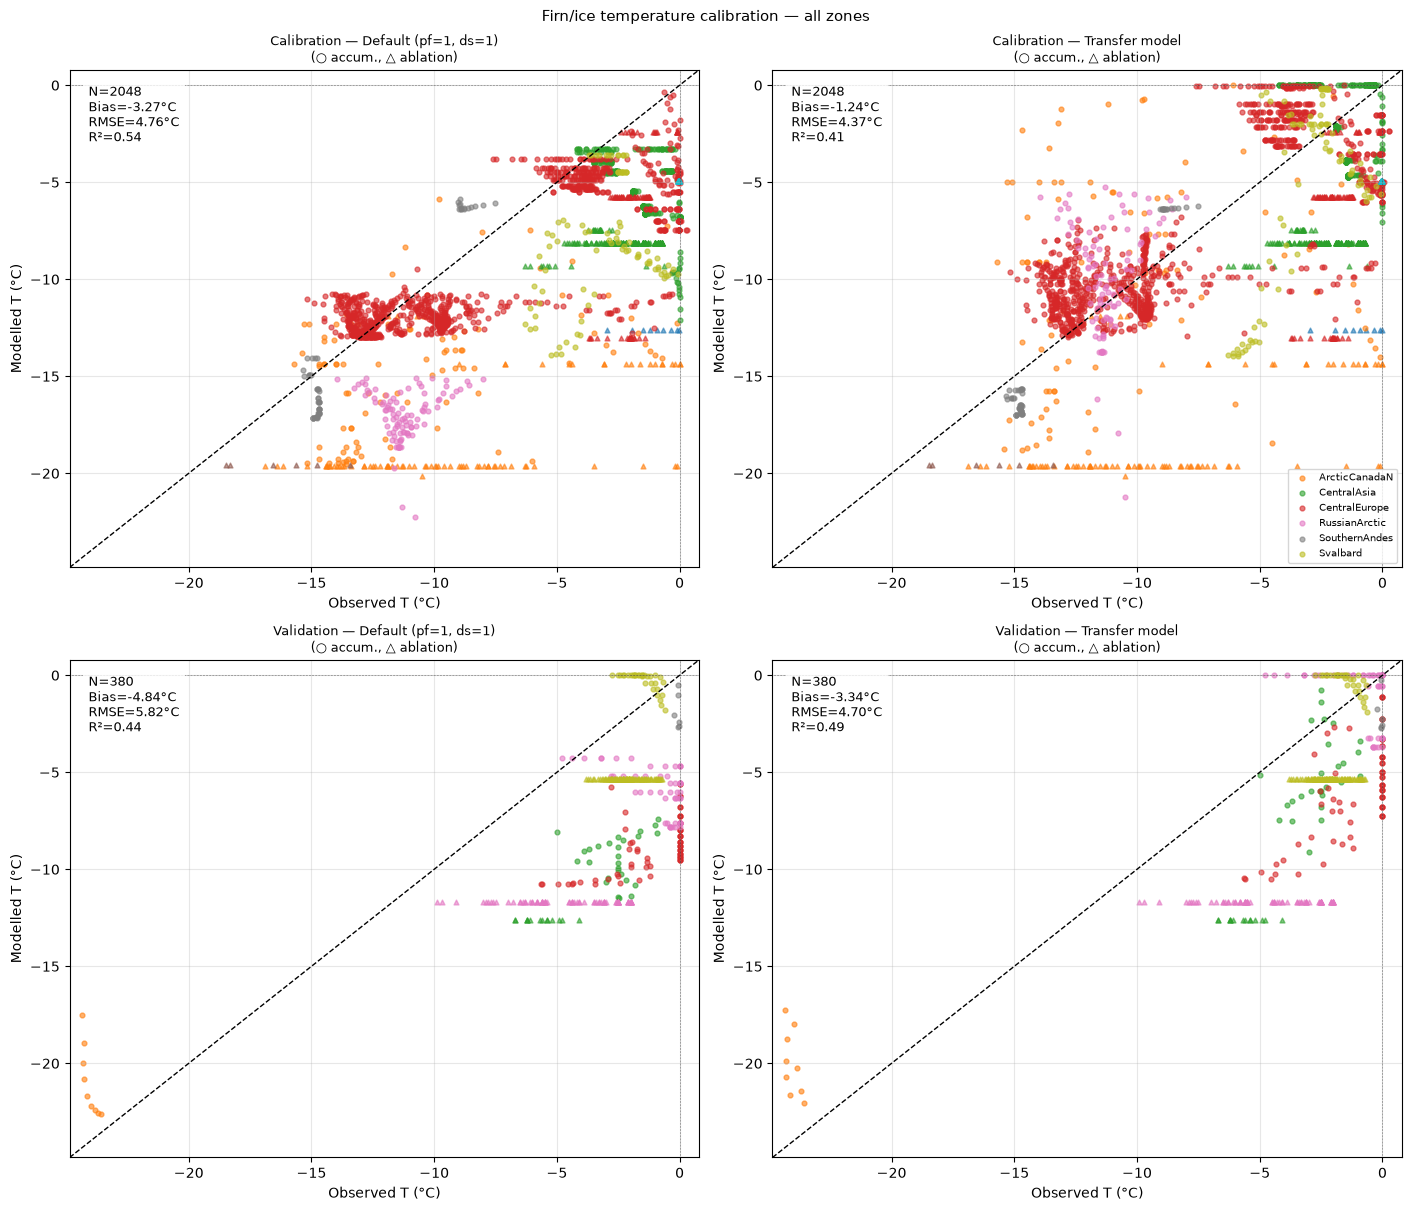

Saved fig_firnice_05_scatter.pdf


In [19]:
from scipy import stats as scipy_stats

regions = sorted(all_df['glogem_region'].unique())
cmap    = plt.cm.tab10(np.linspace(0, 1, max(len(regions), 1)))
col_map = dict(zip(regions, cmap))

# Separate scatter for firn and ice to show both
lim_all = [all_df[['T_obs', 'T_default', 'T_transfer']].min().min() - 0.5,
            all_df[['T_obs', 'T_default', 'T_transfer']].max().max() + 0.5]

fig, axes = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)
panels = [
    (axes[0, 0], 'calibration', 'T_default',  'Calibration — Default (pf=1, ds=1)'),
    (axes[0, 1], 'calibration', 'T_transfer', 'Calibration — Transfer model'),
    (axes[1, 0], 'validation',  'T_default',  'Validation — Default (pf=1, ds=1)'),
    (axes[1, 1], 'validation',  'T_transfer', 'Validation — Transfer model'),
]

for ax, split_name, col, title in panels:
    sub = all_df[all_df['split'] == split_name].dropna(subset=['T_obs', col])
    for region in regions:
        rsub = sub[sub['glogem_region'] == region]
        firn_sub = rsub[rsub['is_firn']]
        ice_sub  = rsub[~rsub['is_firn']]
        if not firn_sub.empty:
            ax.scatter(firn_sub['T_obs'], firn_sub[col], s=12, alpha=0.6,
                       color=col_map[region], marker='o', label=region)
        if not ice_sub.empty:
            ax.scatter(ice_sub['T_obs'],  ice_sub[col],  s=12, alpha=0.6,
                       color=col_map[region], marker='^')  # triangles = ice/ablation
    ax.plot(lim_all, lim_all, 'k--', lw=1)
    ax.set_xlim(lim_all); ax.set_ylim(lim_all)
    ax.set_xlabel('Observed T (°C)')
    ax.set_ylabel('Modelled T (°C)')
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color='k', lw=0.4, ls=':')
    ax.axvline(0, color='k', lw=0.4, ls=':')
    v = sub[['T_obs', col]].dropna()
    bias = (v[col] - v['T_obs']).mean()
    rms  = np.sqrt(((v[col] - v['T_obs'])**2).mean())
    r, _ = scipy_stats.pearsonr(v['T_obs'], v[col])
    r2   = r**2
    ax.text(0.03, 0.97,
            f'N={len(v)}\nBias={bias:+.2f}°C\nRMSE={rms:.2f}°C\nR²={r2:.2f}',
            transform=ax.transAxes, va='top', fontsize=9,
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
    ax.set_title(title + '\n(○ accum., △ ablation)', fontsize=9)
    if split_name == 'calibration' and col == 'T_transfer':
        ax.legend(loc='lower right', fontsize=7, framealpha=0.8)

fig.suptitle('Firn/ice temperature calibration — all zones', fontsize=11)
fig.savefig(FIG_DIR / 'fig_firnice_05_scatter.pdf', bbox_inches='tight')
plt.show()
print('Saved fig_firnice_05_scatter.pdf')

## Write outputs
1. Per-glacier calibration file (`firnicetemp_calibration_CentralEurope.dat`) for GloGEM override
2. IDL coefficient block to paste into `initialise_firnicetemp_spinup.pro`

In [ ]:
# RGI7 → GloGEM glacier_id lookup
try:
    look = pd.read_csv(DATA_DIR / 'rgi7_centraleurope_glims_lookup.csv')
    look['glacier_id'] = look['rgi7_glogem'].str.split('.').str[-1]
    bh = pd.read_csv(GLENGLAT_DIR / 'borehole.csv')
    bh['borehole_id'] = bh['id'].astype(str)
    have_lookup = True
except Exception as e:
    print(f'Lookup not available: {e}')
    have_lookup = False

# File format: glacier_id  perm_frac  dT_scale
# perm_frac is written as 1.000 (scalar default) — not calibrated here.
# read_firnicetemp_calibration.pro expects 3 columns for backward compatibility.
out_lines = ['# glacier_id  perm_frac  dT_scale  # glacier_name  region  n_obs']

for _, row in calib_df.iterrows():
    glogem_id = '?????'
    if have_lookup:
        bh_match = bh[bh['glacier_name'] == row['glacier_name']]
        if not bh_match.empty:
            glims = bh_match['glims_id'].iloc[0]
            lk = look[look['glims_id'] == glims]
            if not lk.empty:
                glogem_id = lk['glacier_id'].iloc[0]
    out_lines.append(
        f'{glogem_id}  1.000  {row["dT_scale_opt"]:.3f}'
        f'  # {row["glacier_name"]}  {row["glogem_region"]}  n={int(row["n_obs"])}'
    )

cal_file = TEST_DIR / 'firnicetemp_calibration_CentralEurope.dat'
with open(cal_file, 'w') as f:
    f.write('\n'.join(out_lines) + '\n')
print(f'Written: {cal_file}')
print('\n'.join(out_lines[:10]))

In [ ]:
# Unscaled IDL coefficients for dT_scale transfer model
reg_ds, sc_ds, cu_ds, c0_ds = transfer_models['ds']

idl_block = f"""; ── Transfer model coefficients (05_firnicetemp_calibration.ipynb) ──────────
; Fit: dT_scale on {len(df_ds)} accumulation-zone glaciers.  perm_frac uses scalar default.
; Predictors: tt[i]=MAAT (°C), t_amp_band[i]=T_amplitude (°C), elev[i]=elevation (m)
; ICE_FRAC = 0.4d  ; defined in initialise_firnicetemp_spinup.pro and firnice_temperature_model.pro
c0_ds = {c0_ds:.6f}d
c1_ds = {cu_ds[0]:.6f}d  ; T_maat
c2_ds = {cu_ds[1]:.6f}d  ; T_amplitude
c3_ds = {cu_ds[2]:.8f}d  ; elevation
"""

idl_loop = """if firnice_temp_calib eq 'y' then begin
    ; Transfer model: dT_scale only — perm_frac uses scalar default from settings.pro.
    ; Predictors: c1=tt[i] (MAAT, °C), c2=t_amp_band[i] (°C), c3=elev[i] (m)
    c0_ds = 1.0d & c1_ds = 0.0d & c2_ds = 0.0d & c3_ds = 0.0d   ; <-- replace with above
    for i = 0, nb-1 do begin
        if firn[i] ne 1 then continue
        firnice_dT_scale_b[i] = (c0_ds + c1_ds*tt[i] + c2_ds*t_amp_band[i] $
            + c3_ds*elev[i]) > 0.2d < 3.0d
    endfor
endif"""

print('── Paste into initialise_firnicetemp_spinup.pro ──────────────────────────────')
print(idl_block)
print(idl_loop)
print('─────────────────────────────────────────────────────────────────────────────')

## Profile comparison — calibrated vs default (validation glaciers)

In [ ]:
show_v     = valid_glaciers[:min(8, len(valid_glaciers))]
depth_line = np.linspace(MIN_DEPTH, MAX_DEPTH, 300)

if not show_v:
    print('No validation glaciers to plot.')
else:
    ncols = 4
    nrows = (len(show_v) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 5), constrained_layout=True)
    axes_flat = np.array(axes).flat

    for ax, gname in zip(axes_flat, show_v):
        gdf = data[data['glacier_name'] == gname]
        if gdf.empty:
            ax.set_visible(False); continue

        T_maat  = gdf['T_maat'].mean()
        dT_fb   = gdf['dT_firn_band'].mean()
        T_amp   = gdf['T_amplitude'].mean()
        elev    = gdf['elevation'].mean()
        region  = gdf['glogem_region'].iloc[0]

        ds_pred = predict_params(T_maat, T_amp, elev)

        # Profiles for firn and ice zones
        T_def_f = [cp_model_single(d, T_maat, dT_fb, 1.0,     True)  for d in depth_line]
        T_tr_f  = [cp_model_single(d, T_maat, dT_fb, ds_pred, True)  for d in depth_line]
        T_def_i = [cp_model_single(d, T_maat, dT_fb, 1.0,     False) for d in depth_line]
        T_tr_i  = [cp_model_single(d, T_maat, dT_fb, ds_pred, False) for d in depth_line]

        firn_obs = gdf[gdf['is_firn']]
        ice_obs  = gdf[~gdf['is_firn']]

        if not firn_obs.empty:
            ax.scatter(firn_obs['T_obs'], firn_obs['depth'], s=14, color='tomato',
                       zorder=4, label='obs (acc.)')
            ax.plot(T_def_f, depth_line, 'steelblue', lw=1.5, ls='--', label='default (acc.)')
            ax.plot(T_tr_f,  depth_line, 'seagreen',  lw=2,
                    label=f'calib (ds={ds_pred:.1f})')
        if not ice_obs.empty:
            ax.scatter(ice_obs['T_obs'], ice_obs['depth'], s=14, color='darkorange',
                       marker='^', zorder=4, label='obs (abl.)')
            ax.plot(T_def_i, depth_line, 'cornflowerblue', lw=1.5, ls='--',
                    label='default (abl.)')
            ax.plot(T_tr_i,  depth_line, 'olive', lw=2, label='calib (abl.)')

        ax.invert_yaxis()
        ax.set_xlabel('T (°C)', fontsize=8)
        ax.set_ylabel('Depth (m)', fontsize=8)
        ax.axvline(0, color='k', lw=0.5, ls=':')
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=6)
        ax.set_title(f'{gname}\n{region}  MAAT={T_maat:.1f}°C  T_amp={T_amp:.1f}°C', fontsize=8)

    for ax in list(axes_flat)[len(show_v):]:
        ax.set_visible(False)

    fig.suptitle('Validation glaciers — default vs calibrated profiles (all zones)', fontsize=11)
    fig.savefig(FIG_DIR / 'fig_firnice_05_profiles_validation.pdf', bbox_inches='tight')
    plt.show()
    print('Saved fig_firnice_05_profiles_validation.pdf')